In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
df = pd.read_csv('exoplanet_data.csv', comment = '#')
print(df)

         pl_name   hostname  default_flag  sy_snum  sy_pnum  discoverymethod  \
0        7 CMa c      7 CMa             0        1        2  Radial Velocity   
1        7 CMa c      7 CMa             1        1        2  Radial Velocity   
2       DMPP-1 b     DMPP-1             1        1        4  Radial Velocity   
3       DMPP-1 b     DMPP-1             0        1        4  Radial Velocity   
4       DMPP-1 c     DMPP-1             1        1        4  Radial Velocity   
..           ...        ...           ...      ...      ...              ...   
578    bet Pic c    bet Pic             0        1        2  Radial Velocity   
579    bet Pic c    bet Pic             1        1        2  Radial Velocity   
580    bet Pic c    bet Pic             0        1        2  Radial Velocity   
581  eps Ind A b  eps Ind A             1        3        1  Radial Velocity   
582  eps Ind A b  eps Ind A             0        3        1  Radial Velocity   

     disc_year           disc_facility 

In [35]:
print(df.shape)
print(df.columns)
#1. pl_rade
#2. pl_bmasselim
#3. pl_radeerr
#4. st_refname
#5. st_metratio

(583, 92)
Index(['pl_name', 'hostname', 'default_flag', 'sy_snum', 'sy_pnum',
       'discoverymethod', 'disc_year', 'disc_facility', 'soltype',
       'pl_controv_flag', 'pl_refname', 'pl_orbper', 'pl_orbpererr1',
       'pl_orbpererr2', 'pl_orbperlim', 'pl_orbsmax', 'pl_orbsmaxerr1',
       'pl_orbsmaxerr2', 'pl_orbsmaxlim', 'pl_rade', 'pl_radeerr1',
       'pl_radeerr2', 'pl_radelim', 'pl_radj', 'pl_radjerr1', 'pl_radjerr2',
       'pl_radjlim', 'pl_bmasse', 'pl_bmasseerr1', 'pl_bmasseerr2',
       'pl_bmasselim', 'pl_bmassj', 'pl_bmassjerr1', 'pl_bmassjerr2',
       'pl_bmassjlim', 'pl_bmassprov', 'pl_orbeccen', 'pl_orbeccenerr1',
       'pl_orbeccenerr2', 'pl_orbeccenlim', 'pl_insol', 'pl_insolerr1',
       'pl_insolerr2', 'pl_insollim', 'pl_eqt', 'pl_eqterr1', 'pl_eqterr2',
       'pl_eqtlim', 'ttv_flag', 'st_refname', 'st_spectype', 'st_teff',
       'st_tefferr1', 'st_tefferr2', 'st_tefflim', 'st_rad', 'st_raderr1',
       'st_raderr2', 'st_radlim', 'st_mass', 'st_masserr1', 's

In [36]:
#Table Label: Planet Name
# Database Column Name: pl_name
# Description: Planet name most commonly used in the literature
# My description: name of planet  

In [37]:
#Table Label: Host Name
# Database Column Name: hostname
# Description: Planet name most commonly used in the literature
# My description: name of star being orbited by exoplanet

In [38]:
#Table Label: Discovery Method
# Database Column Name: discoverymethod
# Description: Method by which the planet was first identified
# My description: how the exoplanet was discovered (transit method vs doppler wobble maybe)

In [39]:
#Table Label: Spectral Type
# Database Column Name: st_spectype
# Description: Classification of the star based on their spectral characteristics following 
#              the Morgan-Keenan system
# My description: classifying star based on luminosity (O B A F G K M)

In [40]:
#Table Label: Equilibrum Temperature [K]
# Database Column Name: pl_eqt
# Description: The equilibrium temperature of the planet as modeled by a black body heated 
# only by its host star, or for directly imaged planets, the effective temperature of the planet required 
# to match the measured luminosity if the planet were a black body
# My description: baseline temperature of a planet based on its distance from its sun and the star’s heat
#                 assuming it is a blackbody

In [41]:
#Table Label: Planet Mass*sin(i) [Jupiter Mass]
# Database Column Name: pl_bmassj
# Description: Minimum mass of a planet as measured by radial velocity, measured in units of masses of Jupiter
# My description: exoplanet mass measured in terms of jupiter masses

In [42]:
exoplanet = df[["pl_name","hostname","discoverymethod","st_spectype","pl_eqt", "pl_bmassj"]]
print(exoplanet)

         pl_name   hostname  discoverymethod st_spectype  pl_eqt  pl_bmassj
0        7 CMa c      7 CMa  Radial Velocity         NaN     NaN   0.912000
1        7 CMa c      7 CMa  Radial Velocity         NaN     NaN   0.870000
2       DMPP-1 b     DMPP-1  Radial Velocity         NaN     NaN   0.052859
3       DMPP-1 b     DMPP-1  Radial Velocity        F8 V   877.0   0.076362
4       DMPP-1 c     DMPP-1  Radial Velocity         NaN     NaN   0.034421
..           ...        ...              ...         ...     ...        ...
578    bet Pic c    bet Pic  Radial Velocity         NaN  1250.0   8.200000
579    bet Pic c    bet Pic  Radial Velocity         NaN     NaN  10.139000
580    bet Pic c    bet Pic  Radial Velocity         NaN     NaN   9.000000
581  eps Ind A b  eps Ind A  Radial Velocity        K5 V   275.0   6.310000
582  eps Ind A b  eps Ind A  Radial Velocity        K2 V     NaN   3.250000

[583 rows x 6 columns]


In [43]:
exoplanet_new= exoplanet.dropna()
print(exoplanet_new)

         pl_name   hostname  discoverymethod st_spectype  pl_eqt  pl_bmassj
3       DMPP-1 b     DMPP-1  Radial Velocity        F8 V   877.0   0.076362
5       DMPP-1 c     DMPP-1  Radial Velocity        F8 V  1239.0   0.030205
7       DMPP-1 d     DMPP-1  Radial Velocity        F8 V  1632.0   0.010540
8       DMPP-1 e     DMPP-1  Radial Velocity        F8 V  1314.0   0.012994
10      DMPP-2 b     DMPP-2  Radial Velocity        F5 V  1000.0   0.437000
..           ...        ...              ...         ...     ...        ...
561   WASP-185 b   WASP-185          Transit        G0 V  1160.0   0.980000
565   WASP-190 b   WASP-190          Transit     F6 IV-V  1500.0   1.000000
569   WASP-192 b   WASP-192          Transit        G0 V  1620.0   2.300000
572       XO-7 b       XO-7          Transit        G0 V  1743.0   0.709000
581  eps Ind A b  eps Ind A  Radial Velocity        K5 V   275.0   6.310000

[70 rows x 6 columns]


In [44]:
print(exoplanet_new.shape)

(70, 6)


In [45]:
#70 columns and 6 rows

In [46]:
print(exoplanet_new.head())
print(exoplanet_new.tail())

     pl_name hostname  discoverymethod st_spectype  pl_eqt  pl_bmassj
3   DMPP-1 b   DMPP-1  Radial Velocity        F8 V   877.0   0.076362
5   DMPP-1 c   DMPP-1  Radial Velocity        F8 V  1239.0   0.030205
7   DMPP-1 d   DMPP-1  Radial Velocity        F8 V  1632.0   0.010540
8   DMPP-1 e   DMPP-1  Radial Velocity        F8 V  1314.0   0.012994
10  DMPP-2 b   DMPP-2  Radial Velocity        F5 V  1000.0   0.437000
         pl_name   hostname  discoverymethod st_spectype  pl_eqt  pl_bmassj
561   WASP-185 b   WASP-185          Transit        G0 V  1160.0      0.980
565   WASP-190 b   WASP-190          Transit     F6 IV-V  1500.0      1.000
569   WASP-192 b   WASP-192          Transit        G0 V  1620.0      2.300
572       XO-7 b       XO-7          Transit        G0 V  1743.0      0.709
581  eps Ind A b  eps Ind A  Radial Velocity        K5 V   275.0      6.310


In [47]:
print(exoplanet_new.columns)

Index(['pl_name', 'hostname', 'discoverymethod', 'st_spectype', 'pl_eqt',
       'pl_bmassj'],
      dtype='object')


In [48]:
#4.4

In [62]:
exoplanet_new.value_counts('discoverymethod')

discoverymethod
Transit            55
Radial Velocity    13
Imaging             2
Name: count, dtype: int64

In [50]:
#discovry methods are radial velocity and the transit method. 
# Radial Velocity 13 one
# transit method has 55, which is the most.
#imaging has two which is the least
#the transit method measured the amount of brightness that the hosts star dimms when
# an exoplanet crosses orbit in our view. We can use it to measure the mass of planet, 
# orbital period, atmospheric composition, and density. 
# the radial velocity method is used to detect exoplanets by measuring the "wobble" 
# of a star caused by an orbiting star's gravity
# imaging Direct imaging uses telescopes to capture actual light from a planet by physically 
#  blocking out the glare of the host star.

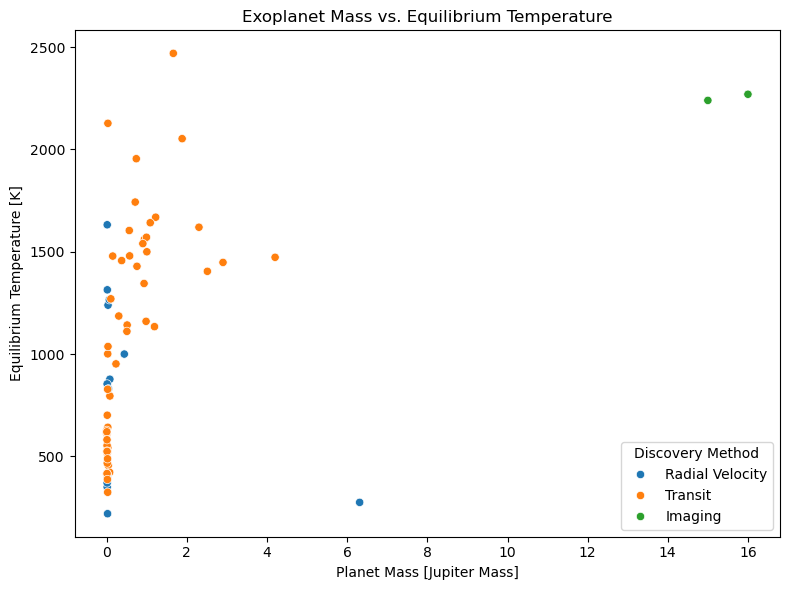

In [64]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=exoplanet_new, x='pl_bmassj', y='pl_eqt', hue='discoverymethod')
plt.title('Exoplanet Mass vs. Equilibrium Temperature')
plt.xlabel('Planet Mass [Jupiter Mass]')
plt.ylabel('Equilibrium Temperature [K]')

plt.legend(title='Discovery Method', loc='lower right')
plt.tight_layout() 
plt.show()

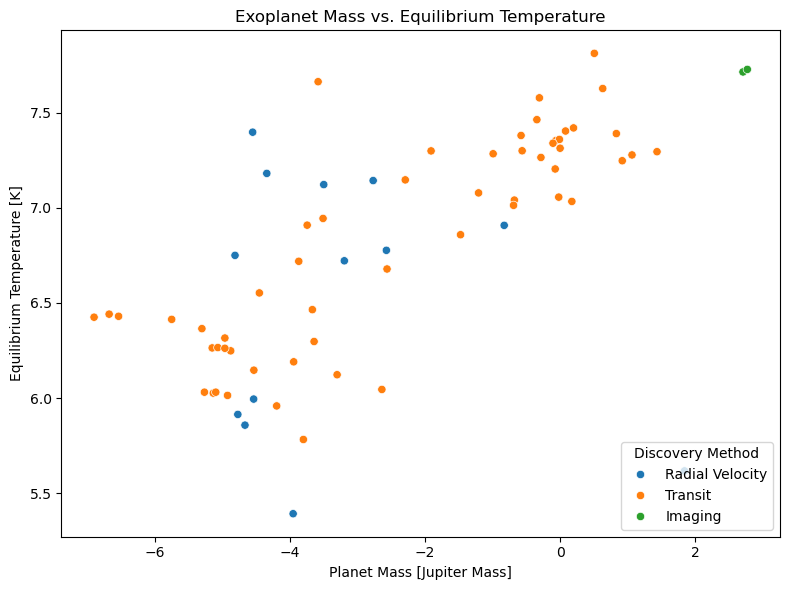

In [66]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=exoplanet_new, x=np.log(exoplanet_new['pl_bmassj']), y=np.log(exoplanet_new['pl_eqt']), 
                hue='discoverymethod')
plt.title('Exoplanet Mass vs. Equilibrium Temperature')
plt.xlabel('Logarithmic Planet Mass [Jupiter Mass]')
plt.ylabel('Logarithmic Equilibrium Temperature [K]')

plt.legend(title='Discovery Method', loc='lower right')
plt.tight_layout() 
plt.show()

In [ ]:
#planets found by imaging method are most likely to be big

In [70]:
exoplanet_new[exoplanet_new['pl_bmassj'] > 5]

,pl_name,hostname,discoverymethod,st_spectype,pl_eqt,pl_bmassj
493,USco1556 b,USco1556 A,Imaging,M3.0 V,2240.0,15.00
494,USco1621 b,USco1621 A,Imaging,M2.5 V,2270.0,16.00
581,eps Ind A b,eps Ind A,Radial Velocity,K5 V,275.0,6.31


In [ ]:
#coldest planet is eps Ind A b

In [75]:
print(exoplanet_new.loc[581,:])

pl_name                eps Ind A b
hostname                 eps Ind A
discoverymethod    Radial Velocity
st_spectype                   K5 V
pl_eqt                       275.0
pl_bmassj                     6.31
Name: 581, dtype: object


In [ ]:
# name: eps IND A b
# index 581
# 275 K
# 6.31 Mjupiter
# orbiting a K5 V star which is not a sun like star (G type)

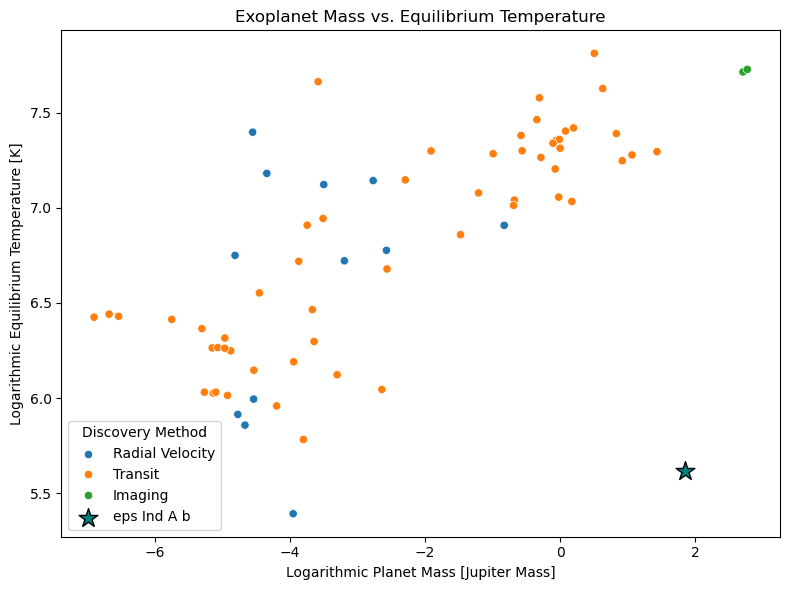

In [86]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=exoplanet_new, x=np.log(exoplanet_new['pl_bmassj']), y=np.log(exoplanet_new['pl_eqt']), 
    hue='discoverymethod')

target = exoplanet_new.loc[581]
target_log_x = np.log(target['pl_bmassj'])
target_log_y = np.log(target['pl_eqt'])

plt.scatter(target_log_x, target_log_y, color='teal', marker='*', s=200, edgecolor='black',    
    label=target['pl_name'])
        
plt.title('Exoplanet Mass vs. Equilibrium Temperature')
plt.xlabel('Logarithmic Planet Mass [Jupiter Mass]')
plt.ylabel('Logarithmic Equilibrium Temperature [K]')

plt.legend(title='Discovery Method', loc='lower left')
plt.tight_layout() 
plt.show()

In [ ]:
# Name of Abstract:A temperate super-Jupiter imaged with JWST in the mid-infrared
#through radial velocity discovery method, there is an exoplanet that is orbiting the star eps Ind A b.
#Yes the star names match along with the temperature of 275 K.
#the planet's brightness makes it special
#Yes the equilibrium temperatures are the same 275 K. However the mass is measured in different units, so 
#difficult to tell.